# Python для анализа данных</a>

## Библиотека `Plotly`

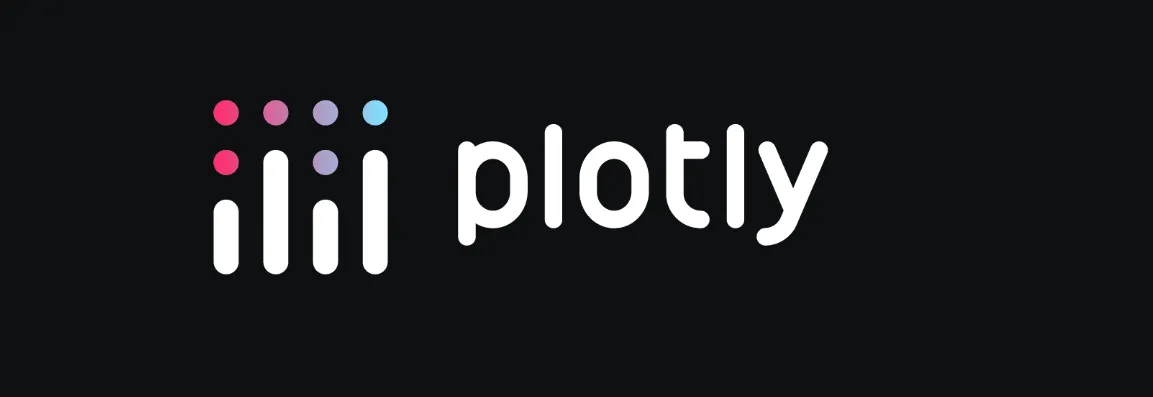

<a target="_blank" href="https://plotly.com/python/">Plotly</a> &mdash; бесплатная графическая библиотека с открытым исходным кодом, в последние годы набирающая популярность в Data Science среде. Ее ключевое преимущество перед `seaborn` и `matplotlib` — удобство построения сложных интерактивных визуализаций — полноценных мини-приложений, которые делают результат работы аналитика более доступным для конечного пользователя.



In [5]:
import numpy as np
import scipy.stats as sps
import pandas as pd
import matplotlib.pyplot as plt
import datetime
from plotly.subplots import make_subplots

import plotly
import plotly.graph_objects as go
import plotly.express as px

### 1. Простые графики

#### График функций

Предположим, мы хотим нарисовать на отрезке $[-1, 1]$ функции $f(x) = x^2$ и $g(x) = \sin(10x)$. Определим значения функций по сетке.

In [3]:
x = np.linspace(-1, 1, 101)
y1 = x**2
y2 = np.sin(10*x)

Построить график с помощью `matplotlib` можно следующим образом.

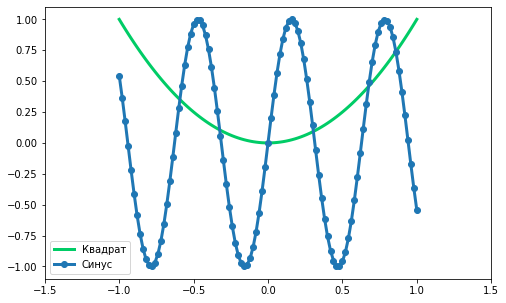

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(x, y1, label='Квадрат', lw=3, color='#00CC66')
plt.plot(x, y2, label='Синус', lw=3, marker='o')
plt.legend()
plt.xlim((-1.5, 1.5))
plt.show()

`plotly` рисует графики с помощью следующей общей конструкции:

```python
    fig = go.Figure()
    fig.add_trace(что рисовать)
    fig.update_layout(параметры фигуры)
    fig.update_xaxes(параметры оси абсцисс)
    fig.update_yaxes(параметры оси ординат)
    fig.show()
```

Теперь нарисуем наши функции с помощью `plotly`.

In [4]:
# объявляем фигуру
fig = go.Figure()

# добавляем первый график
fig.add_trace(
    go.Scatter(
        x=x, y=y1,  # данные
        name='Квадрат',  # имя в легенде
        marker=dict(color='#00CC66'),  # цвет в html-формате
        opacity=0.8,  # прозрачность
        line={'width': 3}  # свойства линии - толщина
    )
)

# добавляем второй график
fig.add_trace(
    go.Scatter(
        x=x, y=y2,  # данные
        mode='lines+markers',  # линии и точки
        name='Синус',  # имя в легенде
        marker=dict(  # свойства маркера
            color='rgba(255,48,0,1)',  # цвет в rgb-формате
            size=7  # размер маркера
        ),
        opacity=0.8,  # прозрачность
        line={'width': 3}  # свойства линии - толщина
    )
)

# свойства фигуры
fig.update_layout(
    height=450, width=700,  # размер фигуры
    title_text='Простой график функций',  # заголовок графика
    title_font_size=16,  # размер заголовка
    plot_bgcolor='rgba(0,0,0,0.05)',  # цвет фона
)

# параметры оси абсцисс
fig.update_xaxes(
    range=[-1.5, 1.5],  # ограничение графика
    zeroline=True,  # рисовать линию x=0
    zerolinewidth=2  # толщина линии x=0
)

# параметры оси ординат
fig.update_yaxes(
    zeroline=True,  # рисовать линию y=0
    zerolinewidth=2,  # толщина линии y=0
    zerolinecolor='LightGray'  # цвет линии y=0
)

# показать график
fig.show()

График интерактивный:
* при наведении мышкой на линию появляется окошко, в которой указаны координаты точки и имя линии;
* с помощью выделения можно указать прямоугольную область, которую нужно приблизить;
* вернуть исходный масштаб можно двойным щелчком или кнопкой на панели сверху;
* кликами по легенде можно убирать линии с графика.


Следующей функцией можно сохранить фигуру в html-формате.

In [5]:
plotly.offline.plot(fig, filename='example.html', auto_open=False)

'example.html'

*Замечание.*
На сайте Plotly содержится полная документация со списком всех возможных параметров. Если параметр принимает в качестве значения словарь других параметров, то в документации приводится также список этих параметров.
Ссылки на документацию для конкретных функций:
* <a target="_blank" href="https://plotly.com/python/reference/scatter/">Scatter</a>;
* <a target="_blank" href="https://plotly.com/python/reference/layout/">update_layout</a>;
* <a target="_blank" href="https://plotly.com/python/reference/layout/xaxis/">update_xaxes</a>;
* <a target="_blank" href="https://plotly.com/python/reference/layout/yaxis/">update_yaxes</a>.

#### Капитализация Apple

Загрузим данные с информацией о капитализации компании Apple в зависимости от месяца.

In [42]:
df = pd.read_csv('/content/apple.csv')
df.head()

,Date,AAPL.Open,AAPL.High,AAPL.Low,AAPL.Close,AAPL.Volume,AAPL.Adjusted,dn,mavg,up,direction
0,2015-02-17,127.489998,128.880005,126.919998,127.830002,63152400,122.905254,106.741052,117.927667,129.114281,Increasing
1,2015-02-18,127.629997,128.779999,127.449997,128.720001,44891700,123.760965,107.842423,118.940333,130.038244,Increasing
2,2015-02-19,128.479996,129.029999,128.330002,128.449997,37362400,123.501363,108.894245,119.889167,130.884089,Decreasing
3,2015-02-20,128.619995,129.500000,128.050003,129.500000,48948400,124.510914,109.785449,120.763500,131.741551,Increasing
4,2015-02-23,130.020004,133.000000,129.660004,133.000000,70974100,127.876074,110.372516,121.720167,133.067817,Increasing


Стандартные поля исторических котировок:

* AAPL.Open — цена открытия в этот день.
* AAPL.High — максимальная цена в течение дня.
* AAPL.Low — минимальная цена в течение дня.
* AAPL.Close — цена закрытия в этот день.
* AAPL.Volume — объём торгов (сколько акций продано/куплено).
* AAPL.Adjusted — скорректированная цена закрытия, учитывающая сплиты и дивиденды.

Построим график по этим данным, к которому добавим также слайдер, предоставляющий возможность выделять интересующий диапазон дат.

In [7]:
fig = go.Figure()

# две кривые
fig.add_trace(go.Scatter(x=df.Date, y=df['AAPL.High'], name="AAPL High"))
fig.add_trace(go.Scatter(x=df.Date, y=df['AAPL.Low'], name="AAPL Low"))

# свойства графика
fig.update_layout(
    title_text='Финансы компании "Apple"',
    title_font_size=20,
    yaxis_title='Стоимость',
    xaxis_rangeslider_visible=True  # слайдер
)

fig.show()

### 2. Несколько графиков

Сгенерируем 5 выборок размера 200 и посчитаем по каждой из них кумулятивные суммы.

In [3]:
x = sps.norm.rvs(size=(5, 200)).cumsum(axis=1)

Визуализируем каждую кривую на своем графике. Мы также свяжем между собой горизонтальные координатные оси. Это свойство позволяет одновременно масштабировать каждый график, что полезно в случае если величины разные по смыслу.

In [7]:
# объявляем сетку графиков
fig = plotly.subplots.make_subplots(
    rows=5, cols=1,  # 5 строк и 1 столбец
    shared_xaxes=True,  # горизонтальные оси связаны при изменении масштаба
    vertical_spacing=0.02  # расстояние между графиками
)

# рисуем каждый график отдельно
for i in range(5):
    fig.add_trace(
        go.Scatter(
            x=np.arange(200), y=x[i]
        ),
        i+1, 1  # расположение графика в сетке, нумерация с 1
    )

fig.show()

#### Датчики

Рассмотрим более сложный пример о <a target="_blank" href="https://archive.ics.uci.edu/ml/datasets/Gas+sensor+array+exposed+to+turbulent+gas+mixtures">датчиках</a>, подверженных воздействию турбулентных газовых смесей. В данных за 5 минут содержатся измерения температуры, относительной влажности воздуха, а также показания 8 датчиков.

Загрузим данные.

In [8]:
data = pd.read_csv('/content/006_Et_M_CO_M', header=None)
data.columns = ['Time (s)', 'Temperature (oC)', 'Relative Humidity (%)',
                'TGS2600', 'TGS2602', 'TGS2602', 'TGS2620',
                'TGS2612', 'TGS2620', 'TGS2611', 'TGS2610']
data.head()

,Time (s),Temperature (oC),Relative Humidity (%),TGS2600,TGS2602,TGS2602,TGS2620,TGS2612,TGS2620,TGS2611,TGS2610
0,1.72,22.45,40.63,347.0,275.0,536.0,624.0,596.0,741.0,668.0,760.0
1,1.74,22.45,40.63,348.0,275.0,537.0,624.0,596.0,740.0,668.0,760.0
2,1.76,22.45,40.63,346.0,275.0,536.0,624.0,596.0,740.0,668.0,760.0
3,1.78,22.45,40.63,349.0,275.0,536.0,624.0,596.0,740.0,668.0,760.0
4,1.80,22.45,40.63,348.0,275.0,536.0,624.0,596.0,741.0,668.0,760.0


Определим какое-то интерпретируемое время.

In [9]:
time = pd.Timestamp('2021-04-03 16:30:00') + data.iloc[:, 0] * pd.Timedelta('1 sec')

Нарисуем график в три ряда, в которых на первые два нанесем температуру и относительную влажность, а на последний &mdash; показания всех датчиков. В данном случае показания датчиков имеют одинаковый смысл и одинаковую размерность, поэтому их можно наносить на один график, а температура и влажность имеют свою размерность, поэтому их необходимо рисовать на отдельном графике. Поскольку все показания датчиков на одном графике, то для удобства анализа стоит этот график сделать шире.

In [10]:
# объявляем сетку графиков
fig = plotly.subplots.make_subplots(
    rows=3, cols=1,  # 3 строки и 1 столбец
    shared_xaxes=True,  # горизонтальные оси связаны при изменении масштаба
    vertical_spacing=0.1,  # расстояние между графиками
    row_heights=[0.25, 0.25, 0.5],  # высота каждой строки
    subplot_titles=['Температура', 'Относительная влажность', 'Показания датчиков']
)

# визуализируем температуру и влажность
for i in [1, 2]:
    fig.add_trace(
        go.Scatter(
            x=time, y=data.iloc[:, i],
            name=data.columns[i],
        ),
        i, 1
    )

# визуализируем показания датчиков
for i in range(8):
    fig.add_trace(
        go.Scatter(
            x=time, y=data.iloc[:, 3+i],
            name=data.columns[3+i]
        ),
        3, 1
    )

fig.show()

Подробнее о `make_subplots` можно почитать в <a target="_blank" href="https://plotly.com/python-api-reference/generated/plotly.subplots.make_subplots.html">документации</a>.

Подробнее о `Scattergl` можно почитать в <a target="_blank" href="https://plotly.com/python/reference/scattergl/">документации</a>.

### 3. Plotly Express

Вместо обычного Plotly можно использовать Plotly Express — набора шаблонов для быстрой и красивой визуализации, подобно тому как seaborn по отношению к matplotlib.

Рассмотрим встроенные в Plotly данные [Gapminder Foundation](https://en.wikipedia.org/wiki/Gapminder_Foundation) — просветительской Шведской организации, которая анализирует финансовое неравенство в мире.

In [35]:
df = px.data.gapminder()
df.head()

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,AFG,4
1,Afghanistan,Asia,1957,30.332,9240934,820.853030,AFG,4
2,Afghanistan,Asia,1962,31.997,10267083,853.100710,AFG,4
3,Afghanistan,Asia,1967,34.020,11537966,836.197138,AFG,4
4,Afghanistan,Asia,1972,36.088,13079460,739.981106,AFG,4



| Поле        | Название на русском           | Описание |
|-------------|-------------------------------|----------|
| `country`   | Страна                        | Название страны (например, `"Afghanistan"`, `"Brazil"`, `"Japan"`). |
| `continent` | Континент                     | Континент, к которому относится страна (например, `"Asia"`, `"Europe"`, `"Africa"`). |
| `year`      | Год                           | Год наблюдения (обычно с 1952 по 2007 с шагом 5 лет). |
| `lifeExp`   | Продолжительность жизни       | Средняя ожидаемая продолжительность жизни при рождении (в **годах**). |
| `pop`       | Население                     | Общая численность населения страны в данном году. |
| `gdpPercap` | ВВП на душу населения         | Валовой внутренний продукт на душу населения (в **долларах США**, скорректированных по паритету покупательной способности — PPP). |
| `iso_alpha` | ISO-код страны (буквенный)    | Трёхбуквенный международный код страны по стандарту **ISO 3166-1 alpha-3** (например, `"AFG"` для Афганистана, `"RUS"` для России). Используется для карт (например, в `px.choropleth`). |
| `iso_num`   | ISO-код страны (цифровой)     | Трёхзначный цифровой код страны по стандарту **ISO 3166-1 numeric** (например, `004` для Афганистана, `643` для России). Реже используется в визуализациях. |

Следующая функция строит интерактивный график, где по одной оси отложен ВВП, по другой — прогноз средней продолжительности жизни. Размер каждой точки на графике пропорционален размеру государства.

На графике присутствует слайдер, с помощью которого можно выбирать конкретный год.

In [13]:
px.scatter(
    df,  # таблица с данными
    x="gdpPercap", y="lifeExp",  # названия колонок, используемых как координата
    animation_frame="year",  # колонка, определяющая слайдер
    animation_group="country",  # колонка, отвечающая за объект (страну)
    size="pop",  # колонка, отвечающая за размер точек
    color="continent",  # колонка, отвечающая за цвет точек
    hover_name="country",  # колонка, отвечающая за подпись информации о точке
    log_x=True,  # логарифмический масштаб
    size_max=55,  # максимальный размер круга
    range_x=[100, 100000], range_y=[25, 90]  # пределы графика
)

Подробнее о `plotly.express.scatter` можно почитать в <a target="_blank" href="https://plotly.com/python-api-reference/generated/plotly.express.scatter.html">документации</a>.

In [36]:
# Фильтруем данные за 2007 год (последний в датасете)
df_2007 = df[df['year'] == 2007]

# Строим хороплет-карту
fig = px.choropleth(
    df_2007,
    locations="iso_alpha",        # трёхбуквенный ISO-код страны (обязательно!)
    color="gdpPercap",           # цвет = ВВП на душу населения
    hover_name="country",        # что показывать при наведении
    color_continuous_scale=px.colors.sequential.Plasma,  # красивая палитра
    projection="natural earth",  # проекция карты (альтернативы: "equirectangular", "orthographic")
    title="ВВП на душу населения по странам (2007 год)"
)

# Настройка отступов
fig.update_layout(margin=dict(t=50, b=0, l=0, r=0))
fig.show()

In [39]:
fig = px.choropleth(
    df_2007,
    locations="iso_alpha",
    color="lifeExp",
    hover_name="country",
    color_continuous_scale="RdYlBu",
    title="Ожидаемая продолжительность жизни (2007)"
)
fig.show()

In [40]:
fig = px.choropleth(
    df,
    locations="iso_alpha",
    color="gdpPercap",
    hover_name="country",
    animation_frame="year",          # ← анимация!
    color_continuous_scale="Plasma",
    projection="natural earth"
)
fig.show()

### 4. Heatmap


In [28]:
df = px.data.medals_wide()
print(df)

        nation  gold  silver  bronze
0  South Korea    24      13      11
1        China    10      15       8
2       Canada     9      12      12


In [29]:
fig = px.imshow(
    df.set_index('nation'),  # используем 'nation' как метки строк
    labels=dict(x="Тип медали", y="Страна", color="Количество"),
    x=["золото", "серебро", "бронза"],
    y=df['nation'],
    color_continuous_scale='Blues',
    title="Распределение олимпийских медалей по странам"
)

fig.update_layout(
    margin=dict(t=50, l=0, r=0, b=0),
    xaxis_title="Тип медали",
    yaxis_title="Страна"
)
fig.show()

In [33]:
df = px.data.tips()

fig = px.density_heatmap(
    df,
    x="total_bill",
    y="tip",
    nbinsx=20,
    nbinsy=20,
    color_continuous_scale="Plasma",
    title="Зависимость чаевых от суммы счёта"
)
fig.show()

Подробнее о `Heatmap` можно почитать в <a target="_blank" href="https://plotly.github.io/plotly.py-docs/generated/plotly.graph_objects.Heatmap.html">документации</a>.

### 5. Картографические данные



In [19]:
df = px.data.carshare()
df.head()

,centroid_lat,centroid_lon,car_hours,peak_hour
0,45.471549,-73.588684,1772.750000,2
1,45.543865,-73.562456,986.333333,23
2,45.487640,-73.642767,354.750000,20
3,45.522870,-73.595677,560.166667,23
4,45.453971,-73.738946,2836.666667,19


In [24]:
df.describe()

,centroid_lat,centroid_lon,car_hours,peak_hour
count,249.000000,249.000000,249.000000,249.000000
mean,45.523417,-73.591834,1092.528782,8.787149
std,0.035177,0.033098,572.187677,7.223874
min,45.448903,-73.738946,33.250000,0.000000
25%,45.497804,-73.618625,665.583333,3.000000
50%,45.527905,-73.587318,1020.916667,5.000000
75%,45.546145,-73.570955,1414.916667,15.000000
max,45.610879,-73.512460,3274.000000,23.000000


centroid_lat, centroid_lon — координаты квадратов (районов) Монреаля,
car_hours — общее количество часов, на которые брали авто в этом районе.

Визуализируем.

In [26]:
# Строим карту плотности спроса на каршеринг в Монреале
fig = px.density_mapbox(
    df,
    lat='centroid_lat',
    lon='centroid_lon',
    z='car_hours',           # количество часов использования авто
    radius=15,
    center=dict(lat=45.5, lon=-73.6),
    zoom=6,
    mapbox_style="carto-positron",
    title="Плотность использования каршеринга в Монреале"
)

fig.update_layout(margin=dict(t=40, b=0, l=0, r=0))
fig.show()

Подробнее о `plotly.express.density_mapbox` можно почитать в <a target="_blank" href="https://plotly.com/python-api-reference/generated/plotly.express.density_mapbox.html">документации</a>.